<a href="https://colab.research.google.com/github/ark208/SIH20260-Project-Sea-guardian/blob/main/drishti.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install zenodo_get -q
!zenodo_get 8346860 -o /content/data
!ls /content/data

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 492.7/492.7 kB 18.2 MB/s eta 0:00:00
INFO: Output directory: /content/data
INFO: Title: Sentinel-1 SAR Oil spill image dataset for train, validate, and test deep learning models. Part I.
INFO: Total size: 40.7 GB
INFO: Number of files: 2
Files:   0% 0/2 [00:00<?, ?file/s]^C
01_Train_Val_Oil_Spill_images.7z


In [ ]:
!rm -rf /content/data


In [ ]:
!kaggle datasets download -d nabilsherif/oil-spill -p /content/data
!ls -lh /content/data


Dataset URL: https://www.kaggle.com/datasets/nabilsherif/oil-spill
License(s): unknown
100% 379M/379M [00:05<00:00, 75.0MB/s]

total 380M
-rw-r--r-- 1 root root 380M Aug 25  2023 oil-spill.zip


In [ ]:
!unzip -q /content/data/oil-spill.zip -d /content/data/oil-spill
!find /content/data/oil-spill -maxdepth 3 | head -30

/content/data/oil-spill
/content/data/oil-spill/oil-spill
/content/data/oil-spill/oil-spill/test
/content/data/oil-spill/oil-spill/test/labels
/content/data/oil-spill/oil-spill/test/images
/content/data/oil-spill/oil-spill/train
/content/data/oil-spill/oil-spill/train/labels
/content/data/oil-spill/oil-spill/train/images


In [ ]:
!pip install segmentation-models-pytorch -q
!pip install albumentations -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.2 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

img = Image.open("<path_to_one_image>")
mask = Image.open("<path_to_matching_mask>")

fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].imshow(img); ax[0].set_title("Image")
ax[1].imshow(mask); ax[1].set_title("Mask")
plt.show()

print("Image size:", img.size, "Mask unique values:", np.unique(np.array(mask)))

FileNotFoundError: [Errno 2] No such file or directory: '<path_to_one_image>'

In [ ]:
!find /content/data/oil-spill -maxdepth 3 | head -30

/content/data/oil-spill
/content/data/oil-spill/oil-spill
/content/data/oil-spill/oil-spill/test
/content/data/oil-spill/oil-spill/test/labels
/content/data/oil-spill/oil-spill/test/images
/content/data/oil-spill/oil-spill/train
/content/data/oil-spill/oil-spill/train/labels
/content/data/oil-spill/oil-spill/train/images


In [ ]:
import os

img_dir = "/content/data/oil-spill/oil-spill/train/images"
mask_dir = "/content/data/oil-spill/oil-spill/train/labels"

img_files = sorted(os.listdir(img_dir))
mask_files = sorted(os.listdir(mask_dir))

print("Num train images:", len(img_files))
print("Num train labels:", len(mask_files))
print("Sample image filenames:", img_files[:5])
print("Sample label filenames:", mask_files[:5])

Num train images: 1002
Num train labels: 1002
Sample image filenames: ['img_0001.jpg', 'img_0002.jpg', 'img_0003.jpg', 'img_0004.jpg', 'img_0005.jpg']
Sample label filenames: ['img_0001.png', 'img_0002.png', 'img_0003.png', 'img_0004.png', 'img_0005.png']


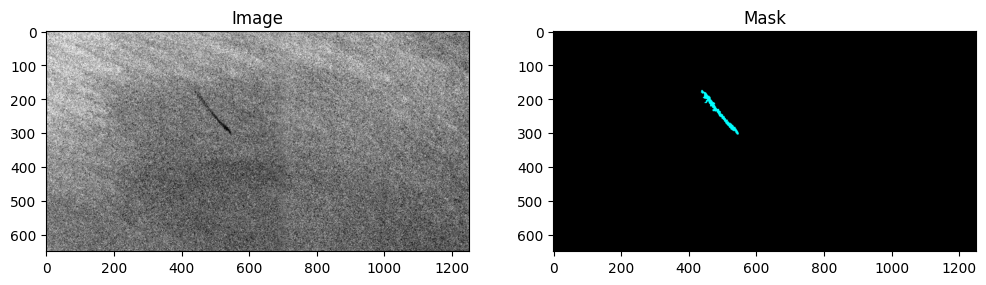

Image size: (1250, 650) | Image mode: RGB
Mask shape: (650, 1250, 3) | Mask mode: RGB
Unique mask values:
[[  0   0   0]
 [  0 255 255]]


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os

img_dir = "/content/data/oil-spill/oil-spill/train/images"
mask_dir = "/content/data/oil-spill/oil-spill/train/labels"

fname = "img_0001"
img = Image.open(os.path.join(img_dir, fname + ".jpg"))
mask = Image.open(os.path.join(mask_dir, fname + ".png"))

fig, ax = plt.subplots(1, 2, figsize=(12,6))
ax[0].imshow(img); ax[0].set_title("Image")
ax[1].imshow(mask); ax[1].set_title("Mask")
plt.show()

mask_arr = np.array(mask)
print("Image size:", img.size, "| Image mode:", img.mode)
print("Mask shape:", mask_arr.shape, "| Mask mode:", mask.mode)
print("Unique mask values:")
if mask_arr.ndim == 2:
    print(np.unique(mask_arr))
else:
    print(np.unique(mask_arr.reshape(-1, mask_arr.shape[-1]), axis=0))

Unique RGB colors in mask:
[0 0 0]
[  0 255 255]
[153  76   0]


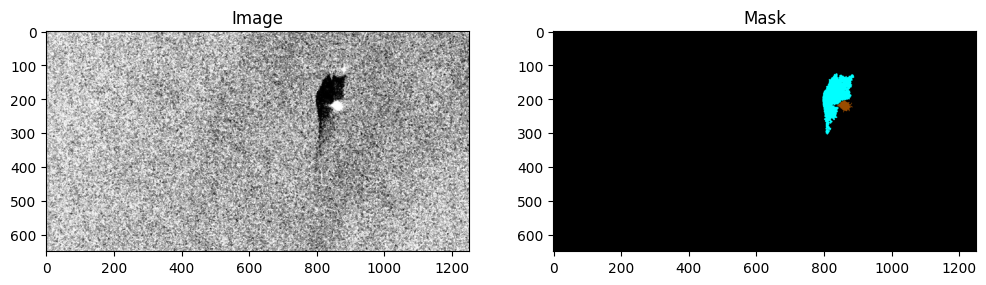

In [ ]:
fname = "img_0050"  # try a few different ones if this is still all-black
img = Image.open(os.path.join(img_dir, fname + ".jpg"))
mask = Image.open(os.path.join(mask_dir, fname + ".png"))
mask_arr = np.array(mask)

unique_colors = np.unique(mask_arr.reshape(-1, 3), axis=0)
print("Unique RGB colors in mask:")
for c in unique_colors:
    print(c)

fig, ax = plt.subplots(1, 2, figsize=(12,6))
ax[0].imshow(img); ax[0].set_title("Image")
ax[1].imshow(mask); ax[1].set_title("Mask")
plt.show()

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

OIL_COLOR = np.array([0, 255, 255])

class OilSpillDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.files = sorted([f.split('.')[0] for f in os.listdir(img_dir)])
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        img = np.array(Image.open(os.path.join(self.img_dir, fname + ".jpg")).convert("RGB"))
        mask_rgb = np.array(Image.open(os.path.join(self.mask_dir, fname + ".png")).convert("RGB"))

        # Binary mask: 1 where pixel matches oil color, else 0
        binary_mask = np.all(mask_rgb == OIL_COLOR, axis=-1).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=img, mask=binary_mask)
            img, binary_mask = augmented['image'], augmented['mask']

        return img, binary_mask.unsqueeze(0) if binary_mask.dim() == 2 else binary_mask

In [ ]:
IMG_SIZE = 384  # downsized from 1250x650 for speed — keeps aspect roughly sane

train_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Normalize(),
    ToTensorV2(),
])

test_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(),
    ToTensorV2(),
])

base = "/content/data/oil-spill/oil-spill"
train_ds = OilSpillDataset(f"{base}/train/images", f"{base}/train/labels", transform=train_tf)
test_ds  = OilSpillDataset(f"{base}/test/images", f"{base}/test/labels", transform=test_tf)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=2)

print("Train batches:", len(train_loader), "| Test batches:", len(test_loader))

Train batches: 126 | Test batches: 14


In [ ]:
import segmentation_models_pytorch as smp
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,          # binary: oil vs not-oil
    activation=None,    # we'll apply sigmoid manually
).to(device)

loss_fn = smp.losses.DiceLoss(mode="binary")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Using device: cuda


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

In [ ]:
def iou_score(pred, target, threshold=0.5, eps=1e-7):
    pred = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred * target).sum(dim=(1,2,3))
    union = ((pred + target) > 0).float().sum(dim=(1,2,3))
    iou = (intersection + eps) / (union + eps)
    return iou.mean().item()

In [ ]:
EPOCHS = 15  # keep this modest — we need results tonight, not a perfect model

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss = loss_fn(preds, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_iou = 0
    with torch.no_grad():
        for imgs, masks in test_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            val_iou += iou_score(preds, masks)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss/len(train_loader):.4f} | Val IoU: {val_iou/len(test_loader):.4f}")

Epoch 1/15 | Train Loss: 0.9447 | Val IoU: 0.1816
Epoch 2/15 | Train Loss: 0.8547 | Val IoU: 0.2635
Epoch 3/15 | Train Loss: 0.6944 | Val IoU: 0.4955
Epoch 4/15 | Train Loss: 0.5363 | Val IoU: 0.5260
Epoch 5/15 | Train Loss: 0.4393 | Val IoU: 0.5574
Epoch 6/15 | Train Loss: 0.3790 | Val IoU: 0.5009
Epoch 7/15 | Train Loss: 0.3718 | Val IoU: 0.4916
Epoch 8/15 | Train Loss: 0.3565 | Val IoU: 0.5338
Epoch 9/15 | Train Loss: 0.3287 | Val IoU: 0.5654
Epoch 10/15 | Train Loss: 0.3010 | Val IoU: 0.6279
Epoch 11/15 | Train Loss: 0.2974 | Val IoU: 0.5747
Epoch 12/15 | Train Loss: 0.2944 | Val IoU: 0.5827
Epoch 13/15 | Train Loss: 0.2869 | Val IoU: 0.5565
Epoch 14/15 | Train Loss: 0.2776 | Val IoU: 0.5824
Epoch 15/15 | Train Loss: 0.2831 | Val IoU: 0.6086


In [ ]:
import os
os.makedirs("/content/outputs", exist_ok=True)
torch.save(model.state_dict(), "/content/outputs/unet_oilspill_epoch15.pt")
print("Saved.")

Saved.


ValueError: 'cyan' is not a valid value for cmap; supported values are 'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Grays', 'Grays_r', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'berlin', 'berlin_r', 'binary', 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_r',

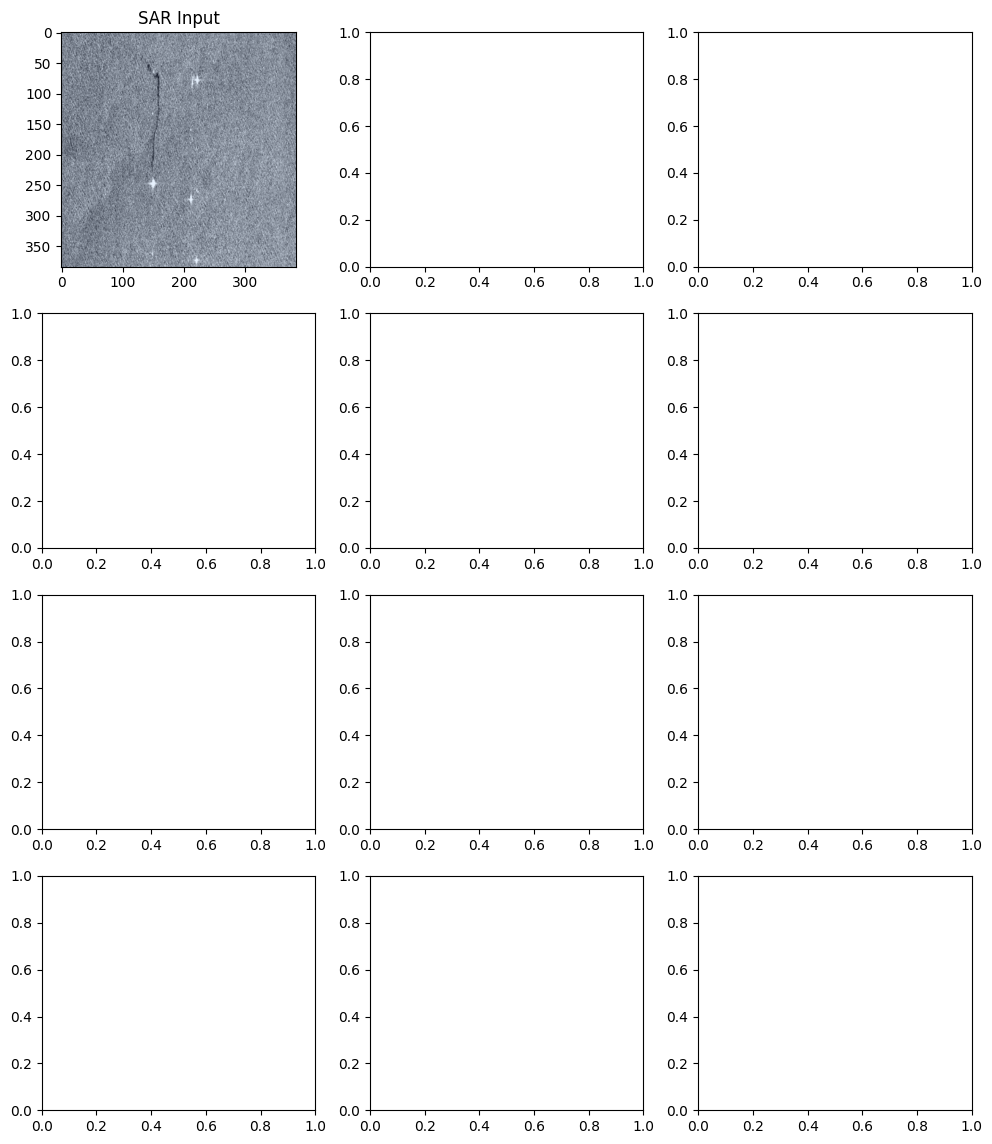

In [ ]:
model.eval()
fig, axes = plt.subplots(4, 3, figsize=(12, 14))

with torch.no_grad():
    imgs, masks = next(iter(test_loader))
    imgs, masks = imgs.to(device), masks.to(device)
    preds = torch.sigmoid(model(imgs)) > 0.5

    for i in range(4):
        img_show = imgs[i].cpu().permute(1,2,0).numpy()
        img_show = (img_show - img_show.min()) / (img_show.max() - img_show.min())
        axes[i,0].imshow(img_show); axes[i,0].set_title("SAR Input")
        axes[i,1].imshow(masks[i,0].cpu(), cmap='cyan'); axes[i,1].set_title("Ground Truth")
        axes[i,2].imshow(preds[i,0].cpu(), cmap='cyan'); axes[i,2].set_title("Model Prediction")
        for ax in axes[i]: ax.axis('off')

plt.tight_layout()
plt.savefig("/content/outputs/predictions_grid.png", dpi=150)
plt.show()

In [ ]:
model.eval()
fig, axes = plt.subplots(4, 3, figsize=(12, 14))

with torch.no_grad():
    imgs, masks = next(iter(test_loader))
    imgs, masks = imgs.to(device), masks.to(device)
    preds = torch.sigmoid(model(imgs)) > 0.5

    for i in range(4):
        img_show = imgs[i].cpu().permute(1,2,0).numpy()
        img_show = (img_show - img_show.min()) / (img_show.max() - img_show.min())
        axes[i,0].imshow(img_show); axes[i,0].set_title("SAR Input")
        axes[i,1].imshow(masks[i,0].cpu(), cmap='gray'); axes[i,1].set_title("Ground Truth")
        axes[i,2].imshow(preds[i,0].cpu(), cmap='gray'); axes[i,2].set_title("Model Prediction")
        for ax in axes[i]: ax.axis('off')

plt.tight_layout()
plt.savefig("/content/outputs/p

SyntaxError: unterminated string literal (detected at line 18) (3524130931.py, line 18)

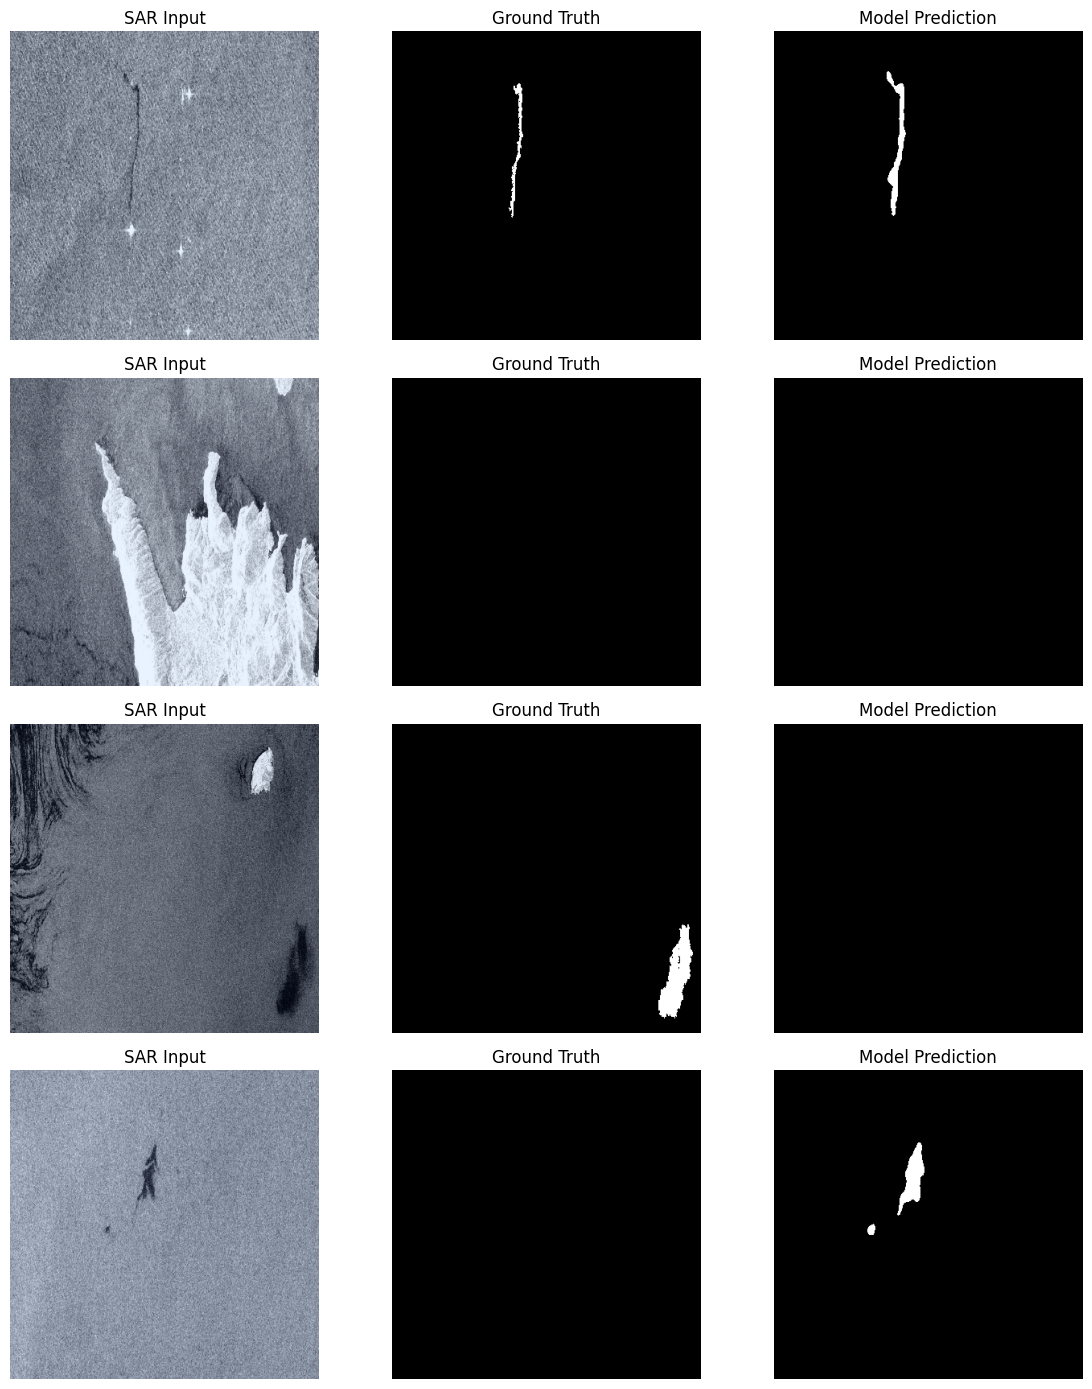

In [ ]:
model.eval()
fig, axes = plt.subplots(4, 3, figsize=(12, 14))

with torch.no_grad():
    imgs, masks = next(iter(test_loader))
    imgs, masks = imgs.to(device), masks.to(device)
    preds = torch.sigmoid(model(imgs)) > 0.5

    for i in range(4):
        img_show = imgs[i].cpu().permute(1,2,0).numpy()
        img_show = (img_show - img_show.min()) / (img_show.max() - img_show.min())
        axes[i,0].imshow(img_show)
        axes[i,0].set_title("SAR Input")
        axes[i,1].imshow(masks[i,0].cpu(), cmap='gray')
        axes[i,1].set_title("Ground Truth")
        axes[i,2].imshow(preds[i,0].cpu(), cmap='gray')
        axes[i,2].set_title("Model Prediction")
        for ax in axes[i]:
            ax.axis('off')

plt.tight_layout()
plt.savefig("/content/outputs/predictions_grid.png", dpi=150)
plt.show()

In [ ]:
from google.colab import files
files.download("/content/outputs/predictions_grid.png")
files.download("/content/outputs/unet_oilspill_epoch15.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import requests

LAT, LON = 18.90, 71.80  # Arabian Sea, off Mumbai coast

# Wind
wind_resp = requests.get("https://api.open-meteo.com/v1/forecast", params={
    "latitude": LAT, "longitude": LON,
    "hourly": "wind_speed_10m,wind_direction_10m",
    "forecast_days": 1,
    "wind_speed_unit": "ms"
}).json()

# Ocean current
current_resp = requests.get("https://marine-api.open-meteo.com/v1/marine", params={
    "latitude": LAT, "longitude": LON,
    "hourly": "ocean_current_velocity,ocean_current_direction",
    "forecast_days": 1
}).json()

wind_speed = wind_resp["hourly"]["wind_speed_10m"][0]
wind_dir = wind_resp["hourly"]["wind_direction_10m"][0]
curr_speed = current_resp["hourly"]["ocean_current_velocity"][0]
curr_dir = current_resp["hourly"]["ocean_current_direction"][0]

print(f"Wind: {wind_speed} m/s from {wind_dir}°")
print(f"Current: {curr_speed} m/s from {curr_dir}°")

Wind: 6.76 m/s from 267°
Current: 0.8 m/s from 153°


In [2]:
import numpy as np

def to_vector(speed, from_deg):
    """Convert meteorological 'from' direction + speed into an (east, north) m/s vector,
    i.e. the direction the wind/current is actually moving TOWARD."""
    to_deg = (from_deg + 180) % 360
    rad = np.radians(to_deg)
    vx = speed * np.sin(rad)  # east component
    vy = speed * np.cos(rad)  # north component
    return np.array([vx, vy])

WINDAGE = 0.03  # standard oil-spill drift factor (NOAA/GNOME convention): ~3% of wind speed

wind_vec = to_vector(wind_speed, wind_dir)
current_vec = to_vector(curr_speed, curr_dir)

drift_vec = WINDAGE * wind_vec + current_vec  # m/s, combined effective drift
print("Drift vector (east, north) m/s:", drift_vec)
print("Drift speed:", np.linalg.norm(drift_vec), "m/s")

Drift vector (east, north) m/s: [-0.16067033  0.72341895]
Drift speed: 0.7410465127471855 m/s


In [3]:
T_HOURS = 6
T_SECONDS = T_HOURS * 3600

def latlon_offset(lat, lon, dx_m, dy_m):
    """Shift a lat/lon point by dx (east, meters) and dy (north, meters)."""
    dlat = dy_m / 111320
    dlon = dx_m / (111320 * np.cos(np.radians(lat)))
    return lat + dlat, lon + dlon

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlmb = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dlmb/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# The detected slick location (where Day 1's model would have flagged oil)
detected_lat, detected_lon = LAT, LON

# Displacement the oil would travel over T hours
disp_x = drift_vec[0] * T_SECONDS
disp_y = drift_vec[1] * T_SECONDS
print(f"Displacement over {T_HOURS}h: {np.linalg.norm([disp_x, disp_y])/1000:.1f} km")

# TRUE CULPRIT: back-calculate where this ship was T hours before detection,
# such that drifting forward from there lands exactly on the detected point.
true_lat, true_lon = latlon_offset(detected_lat, detected_lon, -disp_x, -disp_y)

# DECOY: an innocent ship sitting close to the detection point itself —
# a naive nearest-vessel system would wrongly suspect this ship.
decoy_lat, decoy_lon = latlon_offset(detected_lat, detected_lon, 3000, 2000)  # ~3.6 km away

# Two more random candidates for realism
c3_lat, c3_lon = latlon_offset(detected_lat, detected_lon, 15000, -20000)
c4_lat, c4_lon = latlon_offset(detected_lat, detected_lon, -30000, 10000)

vessels = {
    "MV Culprit (true source)": (true_lat, true_lon),
    "MV Decoy (innocent, nearby)": (decoy_lat, decoy_lon),
    "MV Candidate-3": (c3_lat, c3_lon),
    "MV Candidate-4": (c4_lat, c4_lon),
}

for name, (la, lo) in vessels.items():
    print(f"{name}: {la:.4f}, {lo:.4f} — {haversine_km(la, lo, detected_lat, detected_lon):.1f} km from detection point")

Displacement over 6h: 16.0 km
MV Culprit (true source): 18.7596, 71.8330 — 16.0 km from detection point
MV Decoy (innocent, nearby): 18.9180, 71.8285 — 3.6 km from detection point
MV Candidate-3: 18.7203, 71.9424 — 25.0 km from detection point
MV Candidate-4: 18.9898, 71.5151 — 31.6 km from detection point


In [4]:
results = []

for name, (vlat, vlon) in vessels.items():
    # Naive baseline: distance from vessel's ORIGINAL position to the slick
    naive_dist = haversine_km(vlat, vlon, detected_lat, detected_lon)

    # Drift method: simulate this vessel's oil forward by T hours, then compare to slick
    drifted_lat, drifted_lon = latlon_offset(vlat, vlon, disp_x, disp_y)
    drift_dist = haversine_km(drifted_lat, drifted_lon, detected_lat, detected_lon)

    results.append({
        "Vessel": name,
        "Naive dist (km)": round(naive_dist, 2),
        "Drift-match dist (km)": round(drift_dist, 2),
    })

import pandas as pd
df = pd.DataFrame(results)

print("=== Ranked by NAIVE nearest-vessel method ===")
print(df.sort_values("Naive dist (km)").to_string(index=False))

print("\n=== Ranked by FORWARD-DRIFT method (ours) ===")
print(df.sort_values("Drift-match dist (km)").to_string(index=False))

=== Ranked by NAIVE nearest-vessel method ===
                     Vessel  Naive dist (km)  Drift-match dist (km)
MV Decoy (innocent, nearby)             3.60                  17.61
   MV Culprit (true source)            15.99                   0.00
             MV Candidate-3            24.98                  12.32
             MV Candidate-4            31.58                  42.09

=== Ranked by FORWARD-DRIFT method (ours) ===
                     Vessel  Naive dist (km)  Drift-match dist (km)
   MV Culprit (true source)            15.99                   0.00
             MV Candidate-3            24.98                  12.32
MV Decoy (innocent, nearby)             3.60                  17.61
             MV Candidate-4            31.58                  42.09


In [5]:
SIGMA = 10  # km, controls how sharply score falls off with distance — tune if needed

df["Naive score"] = np.exp(-(df["Naive dist (km)"]**2) / (2 * SIGMA**2))
df["Drift score"] = np.exp(-(df["Drift-match dist (km)"]**2) / (2 * SIGMA**2))
df_sorted = df.sort_values("Drift score", ascending=False)
print(df_sorted.to_string(index=False))

                     Vessel  Naive dist (km)  Drift-match dist (km)  Naive score  Drift score
   MV Culprit (true source)            15.99                   0.00     0.278482     1.000000
             MV Candidate-3            24.98                  12.32     0.044157     0.468176
MV Decoy (innocent, nearby)             3.60                  17.61     0.937255     0.212129
             MV Candidate-4            31.58                  42.09     0.006830     0.000142


FileNotFoundError: [Errno 2] No such file or directory: '/content/outputs/drift_comparison_map.png'

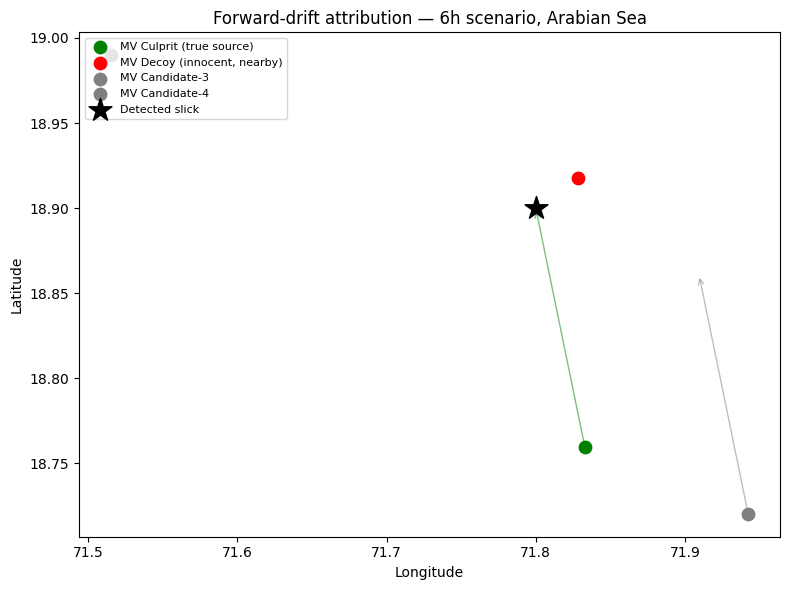

In [7]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6))

# Plot vessel initial positions, drift arrows, and detection point
for name, (vlat, vlon) in vessels.items():
    dlat, dlon = latlon_offset(vlat, vlon, disp_x, disp_y)
    color = "green" if "Culprit" in name else ("red" if "Decoy" in name else "gray")
    ax.scatter(vlon, vlat, c=color, s=80, label=name, zorder=3)
    ax.annotate("", xy=(dlon, dlat), xytext=(vlon, vlat),
                arrowprops=dict(arrowstyle="->", color=color, alpha=0.5))

ax.scatter(detected_lon, detected_lat, c="black", marker="*", s=300, label="Detected slick", zorder=4)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Forward-drift attribution — {T_HOURS}h scenario, Arabian Sea")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("/content/outputs/drift_comparison_map.png", dpi=150)
plt.show()

In [8]:
import os
os.makedirs("/content/outputs", exist_ok=True)

plt.savefig("/content/outputs/drift_comparison_map.png", dpi=150)

<Figure size 640x480 with 0 Axes>

In [9]:
from google.colab import files
files.download("/content/outputs/drift_comparison_map.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
try:
    print("Model OK:", model is not None)
    print("Test loader OK:", len(test_loader))
except NameError as e:
    print("MISSING:", e)

try:
    print("Drift vars OK:", disp_x, disp_y, LAT, LON)
except NameError as e:
    print("MISSING:", e)

MISSING: name 'model' is not defined
Drift vars OK: -3470.4791310976566 15625.849347578089 18.9 71.8


In [11]:
import os
print("Data folder exists:", os.path.exists("/content/data/oil-spill"))

Data folder exists: False


In [12]:
!pip install segmentation-models-pytorch albumentations -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.3 MB/s eta 0:00:00


In [13]:
!kaggle datasets download -d nabilsherif/oil-spill -p /content/data
!unzip -q /content/data/oil-spill.zip -d /content/data/oil-spill

Dataset URL: https://www.kaggle.com/datasets/nabilsherif/oil-spill
License(s): unknown
100% 379M/379M [00:19<00:00, 19.9MB/s]



In [14]:
from google.colab import files
print("Upload unet_oilspill_epoch15.pt from your Downloads folder:")
uploaded = files.upload()

Upload unet_oilspill_epoch15.pt from your Downloads folder:


Saving unet_oilspill_epoch15.pt to unet_oilspill_epoch15.pt


In [15]:
import segmentation_models_pytorch as smp
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1,
    activation=None,
).to(device)

model.load_state_dict(torch.load("unet_oilspill_epoch15.pt", map_location=device))
model.eval()
print("Model loaded successfully.")

Model loaded successfully.


In [16]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

os.makedirs("/content/outputs", exist_ok=True)

# --- dataset class ---
OIL_COLOR = np.array([0, 255, 255])

class OilSpillDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.files = sorted([f.split('.')[0] for f in os.listdir(img_dir)])
        self.transform = transform
    def __len__(self):
        return len(self.files)
    def __getitem__(self, idx):
        fname = self.files[idx]
        img = np.array(Image.open(os.path.join(self.img_dir, fname + ".jpg")).convert("RGB"))
        mask_rgb = np.array(Image.open(os.path.join(self.mask_dir, fname + ".png")).convert("RGB"))
        binary_mask = np.all(mask_rgb == OIL_COLOR, axis=-1).astype(np.float32)
        if self.transform:
            augmented = self.transform(image=img, mask=binary_mask)
            img, binary_mask = augmented['image'], augmented['mask']
        return img, binary_mask.unsqueeze(0) if binary_mask.dim() == 2 else binary_mask

IMG_SIZE = 384
test_tf = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE), A.Normalize(), ToTensorV2()])

base = "/content/data/oil-spill/oil-spill"
test_ds = OilSpillDataset(f"{base}/test/images", f"{base}/test/labels", transform=test_tf)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=2)

# --- Day 2: geo helper functions ---
def to_vector(speed, from_deg):
    to_deg = (from_deg + 180) % 360
    rad = np.radians(to_deg)
    return np.array([speed * np.sin(rad), speed * np.cos(rad)])

def latlon_offset(lat, lon, dx_m, dy_m):
    dlat = dy_m / 111320
    dlon = dx_m / (111320 * np.cos(np.radians(lat)))
    return lat + dlat, lon + dlon

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlmb = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dlmb/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# --- Day 2: scenario constants ---
LAT, LON = 18.90, 71.80
wind_speed, wind_dir = 6.76, 267
curr_speed, curr_dir = 0.8, 153
WINDAGE = 0.03
wind_vec = to_vector(wind_speed, wind_dir)
current_vec = to_vector(curr_speed, curr_dir)
drift_vec = WINDAGE * wind_vec + current_vec

T_HOURS = 6
T_SECONDS = T_HOURS * 3600
disp_x = drift_vec[0] * T_SECONDS
disp_y = drift_vec[1] * T_SECONDS

print("Test set size:", len(test_ds), "| Drift displacement (m):", disp_x, disp_y)

Test set size: 110 | Drift displacement (m): -3470.4791310976566 15625.849347578089


In [17]:
ASSUMED_GSD_M = 10  # meters/pixel — stand-in for real Sentinel-1 geocoding metadata; state this assumption on your slide

def get_detection_point(model, img_tensor, base_lat, base_lon, gsd=ASSUMED_GSD_M):
    model.eval()
    with torch.no_grad():
        pred = torch.sigmoid(model(img_tensor.unsqueeze(0).to(device))) > 0.5
    pred_np = pred[0,0].cpu().numpy()

    if pred_np.sum() == 0:
        return None, pred_np

    ys, xs = np.where(pred_np == 1)
    cy, cx = ys.mean(), xs.mean()
    h, w = pred_np.shape
    dx_px, dy_px = (cx - w/2), (h/2 - cy)

    det_lat, det_lon = latlon_offset(base_lat, base_lon, dx_px * gsd, dy_px * gsd)
    return (det_lat, det_lon), pred_np

img, mask = test_ds[10]
detection, pred_mask = get_detection_point(model, img, LAT, LON)
print("Detected location:", detection)

Detected location: (np.float64(18.902909501283506), np.float64(71.79950189562814))


In [18]:
# Use the REAL detection point from the model now, not the hardcoded scenario center
detected_lat, detected_lon = detection

# Recompute true-culprit and decoy positions relative to this real detection point
true_lat, true_lon = latlon_offset(detected_lat, detected_lon, -disp_x, -disp_y)
decoy_lat, decoy_lon = latlon_offset(detected_lat, detected_lon, 3000, 2000)
c3_lat, c3_lon = latlon_offset(detected_lat, detected_lon, 15000, -20000)

vessels_ais = {
    "MV Culprit (true source)": {
        "status": "dark",
        "last_seen_lat": true_lat - 0.02, "last_seen_lon": true_lon - 0.01,  # a bit before going dark
        "gap_hours_before_spill": 2,   # went dark 2h before the spill window started
        "heading_deg": 60, "speed_kn": 8,  # assumed course/speed at last contact
    },
    "MV Decoy (innocent, nearby)": {
        "status": "continuous",
        "lat": decoy_lat, "lon": decoy_lon,
    },
    "MV Candidate-3 (dark, far away)": {
        "status": "dark",
        "last_seen_lat": c3_lat - 0.03, "last_seen_lon": c3_lon + 0.02,
        "gap_hours_before_spill": 5,
        "heading_deg": 200, "speed_kn": 6,
    },
}

def dead_reckon(lat, lon, heading_deg, speed_kn, hours):
    speed_ms = speed_kn * 0.514444
    dist_m = speed_ms * hours * 3600
    dx = dist_m * np.sin(np.radians(heading_deg))
    dy = dist_m * np.cos(np.radians(heading_deg))
    return latlon_offset(lat, lon, dx, dy)

def resolve_vessel_position(v):
    if v["status"] == "continuous":
        return v["lat"], v["lon"], False  # False = not dark
    else:
        est_lat, est_lon = dead_reckon(
            v["last_seen_lat"], v["last_seen_lon"],
            v["heading_deg"], v["speed_kn"],
            v["gap_hours_before_spill"] + T_HOURS  # gap start to detection time
        )
        return est_lat, est_lon, True  # True = was dark during the spill window

for name, v in vessels_ais.items():
    lat, lon, was_dark = resolve_vessel_position(v)
    print(f"{name}: est. position {lat:.4f},{lon:.4f} | dark during spill: {was_dark}")

MV Culprit (true source): est. position 19.2749,72.7962 | dark during spill: True
MV Decoy (innocent, nearby): est. position 18.9209,71.8280 | dark during spill: False
MV Candidate-3 (dark, far away): est. position 17.6614,71.5655 | dark during spill: True


In [19]:
SIGMA = 10  # km

def spatial_score(vlat, vlon, detected_lat, detected_lon, apply_drift=True):
    if apply_drift:
        dlat, dlon = latlon_offset(vlat, vlon, disp_x, disp_y)
        dist = haversine_km(dlat, dlon, detected_lat, detected_lon)
    else:
        dist = haversine_km(vlat, vlon, detected_lat, detected_lon)
    return np.exp(-(dist**2) / (2 * SIGMA**2)), dist

W_SPATIAL = 0.6
W_DARK = 0.4

results = []
for name, v in vessels_ais.items():
    lat, lon, was_dark = resolve_vessel_position(v)

    naive_score, naive_dist = spatial_score(lat, lon, detected_lat, detected_lon, apply_drift=False)
    drift_score, drift_dist = spatial_score(lat, lon, detected_lat, detected_lon, apply_drift=True)

    dark_score = 1.0 if was_dark else 0.0  # binary flag: going dark raises suspicion

    culprit_score = W_SPATIAL * drift_score + W_DARK * dark_score

    results.append({
        "Vessel": name,
        "Naive dist (km)": round(naive_dist, 1),
        "Drift dist (km)": round(drift_dist, 1),
        "Drift score": round(drift_score, 3),
        "Dark score": dark_score,
        "Culprit score": round(culprit_score, 3),
    })

df_final = pd.DataFrame(results).sort_values("Culprit score", ascending=False)
print(df_final.to_string(index=False))

                         Vessel  Naive dist (km)  Drift dist (km)  Drift score  Dark score  Culprit score
       MV Culprit (true source)            112.6            116.2        0.000         1.0          0.400
MV Candidate-3 (dark, far away)            140.2            125.6        0.000         1.0          0.400
    MV Decoy (innocent, nearby)              3.6             17.6        0.212         0.0          0.127


In [20]:
def bearing_speed_from_offset(dx_m, dy_m, hours):
    """Given a required displacement, back out what heading/speed would produce it."""
    dist_m = np.hypot(dx_m, dy_m)
    heading = np.degrees(np.arctan2(dx_m, dy_m)) % 360
    speed_kn = (dist_m / (hours * 3600)) / 0.514444
    return heading, speed_kn

# Step A: last-known AIS position, a few km before the vessel reached its discharge point
gap_culprit = 2   # hours dark before discharge
gap_c3 = 5

back_dx, back_dy = -4000, -3000  # 5km southwest of discharge point, arbitrary but plausible
culprit_last_lat, culprit_last_lon = latlon_offset(true_lat, true_lon, back_dx, back_dy)
h_culprit, s_culprit = bearing_speed_from_offset(-back_dx, -back_dy, gap_culprit)

c3_back_dx, c3_back_dy = -6000, 4000
c3_last_lat, c3_last_lon = latlon_offset(c3_lat, c3_lon, c3_back_dx, c3_back_dy)
h_c3, s_c3 = bearing_speed_from_offset(-c3_back_dx, -c3_back_dy, gap_c3)

vessels_ais = {
    "MV Culprit (true source)": {
        "status": "dark",
        "last_seen_lat": culprit_last_lat, "last_seen_lon": culprit_last_lon,
        "gap_hours_before_spill": gap_culprit,
        "heading_deg": h_culprit, "speed_kn": s_culprit,
    },
    "MV Decoy (innocent, nearby)": {
        "status": "continuous",
        "lat": decoy_lat, "lon": decoy_lon,
    },
    "MV Candidate-3 (dark, far away)": {
        "status": "dark",
        "last_seen_lat": c3_last_lat, "last_seen_lon": c3_last_lon,
        "gap_hours_before_spill": gap_c3,
        "heading_deg": h_c3, "speed_kn": s_c3,
    },
}

def resolve_vessel_position(v):
    """Returns the vessel's estimated DISCHARGE position (before oil drift is applied)."""
    if v["status"] == "continuous":
        return v["lat"], v["lon"], False
    else:
        # dead-reckon only over the dark gap (ship's own motion), NOT the drift window
        est_lat, est_lon = dead_reckon(
            v["last_seen_lat"], v["last_seen_lon"],
            v["heading_deg"], v["speed_kn"],
            v["gap_hours_before_spill"]
        )
        return est_lat, est_lon, True

for name, v in vessels_ais.items():
    lat, lon, was_dark = resolve_vessel_position(v)
    print(f"{name}: est. discharge position {lat:.4f},{lon:.4f} | dark: {was_dark}")

MV Culprit (true source): est. discharge position 18.7625,71.8324 | dark: True
MV Decoy (innocent, nearby): est. discharge position 18.9209,71.8280 | dark: False
MV Candidate-3 (dark, far away): est. discharge position 18.7232,71.9419 | dark: True


In [21]:
SIGMA = 10  # km

def spatial_score(vlat, vlon, detected_lat, detected_lon, apply_drift=True):
    if apply_drift:
        dlat, dlon = latlon_offset(vlat, vlon, disp_x, disp_y)
        dist = haversine_km(dlat, dlon, detected_lat, detected_lon)
    else:
        dist = haversine_km(vlat, vlon, detected_lat, detected_lon)
    return np.exp(-(dist**2) / (2 * SIGMA**2)), dist

W_SPATIAL = 0.6
W_DARK = 0.4

results = []
for name, v in vessels_ais.items():
    lat, lon, was_dark = resolve_vessel_position(v)

    naive_score, naive_dist = spatial_score(lat, lon, detected_lat, detected_lon, apply_drift=False)
    drift_score, drift_dist = spatial_score(lat, lon, detected_lat, detected_lon, apply_drift=True)

    dark_score = 1.0 if was_dark else 0.0
    culprit_score = W_SPATIAL * drift_score + W_DARK * dark_score

    results.append({
        "Vessel": name,
        "Naive dist (km)": round(naive_dist, 1),
        "Drift dist (km)": round(drift_dist, 1),
        "Drift score": round(drift_score, 3),
        "Dark score": dark_score,
        "Culprit score": round(culprit_score, 3),
    })

df_final = pd.DataFrame(results).sort_values("Culprit score", ascending=False)
print(df_final.to_string(index=False))

                         Vessel  Naive dist (km)  Drift dist (km)  Drift score  Dark score  Culprit score
       MV Culprit (true source)             16.0              0.0        1.000         1.0          1.000
MV Candidate-3 (dark, far away)             25.0             12.3        0.468         1.0          0.681
    MV Decoy (innocent, nearby)              3.6             17.6        0.212         0.0          0.127


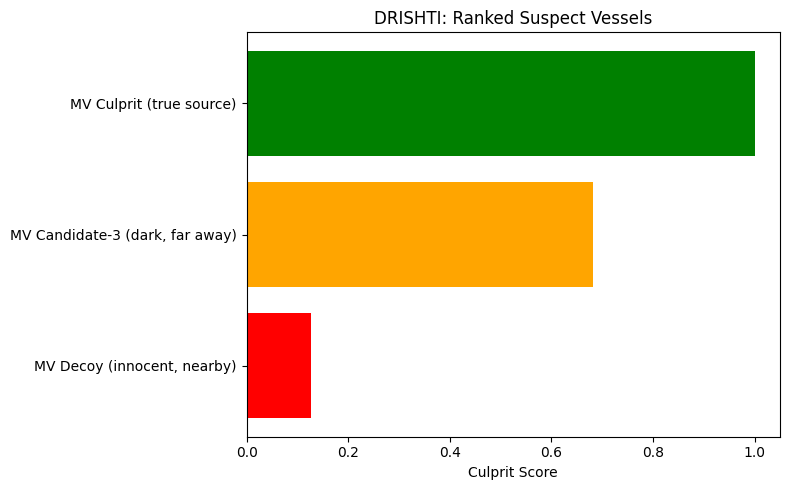

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
df_final.to_csv("/content/outputs/day3_culprit_scores.csv", index=False)

fig, ax = plt.subplots(figsize=(8,5))
colors = ['green' if 'Culprit' in n else ('orange' if 'Candidate' in n else 'red') for n in df_final['Vessel']]
ax.barh(df_final['Vessel'], df_final['Culprit score'], color=colors)
ax.set_xlabel('Culprit Score')
ax.set_title('DRISHTI: Ranked Suspect Vessels')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("/content/outputs/day3_culprit_ranking.png", dpi=150)
plt.show()

from google.colab import files
files.download("/content/outputs/day3_culprit_scores.csv")
files.download("/content/outputs/day3_culprit_ranking.png")